# 13주차: 모델 해석 가능성 · 공정성 · 배포 고려사항
### 📊 데이터: sklearn breast_cancer + 가상 교육 데이터 — 해석·공정성·배포의 세 축
---
## 차시 1
- **해석 가능성**: 모델의 예측 근거를 인간이 이해할 수 있는 정도
- **모델별 스펙트럼**: 선형 회귀(높음) → 결정 트리 → RF → GBM(낮음)
- **기존 피처 중요도의 한계**: 모델 의존적 / 훈련 데이터 기반 / 상관 피처 분산
- **순열 중요도**: 「피처를 셔플하고 성능 하락을 측정」 — 모델 비의존적 + 테스트 데이터 기반
- **글로벌 vs. 로컬 해석**: 순열 중요도(전체) / SHAP·LIME(개별 예측, 개념만 소개)

## 차시 2
- **오해 1**: "ML은 객관적" → 아니다. ML = 거울, 왜곡된 현실을 정확하게 반사
- **오해 2**: "보호 속성 제거 = 공정" → 아니다. 대리 변수(Proxy Variable)로 간접 차별
- **공정성 점검**: 보호 속성별 성능 분리 비교 — 전체 정확도만 보면 편향을 놓침
- **공정성 정의**: 비율 동등 / 정확도 동등 / 개인 공정성 — 서로 충돌 가능
- **교사 역할**: 인식 → 점검 → 판단 → 소통 — 「모델은 참고, 최종 결정은 사람이」

## 차시 3
- **permutation_importance 코드 실행** — 차시 1 원리를 코드로 실현
- **feature_importances_와 비교**: 두 방법이 같은 결과를 내는가? 다르다면 왜?
- **데이터 드리프트**: 시간이 지나면 모델이 「낡는다」 — 피처/타겟/관계 변화
- **성능 모니터링**: 기준선 기록 → 주기적 확인 → 재학습 판단
- **의사결정 한계**: 모델 예측 ≠ 최종 결정 (5가지 이유)

---
## Step 1. 라이브러리 임포트

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

print(f"scikit-learn: {sklearn.__version__}")
print(f"Python: {sys.version.split()[0]}")

scikit-learn: 1.6.1
Python: 3.12.12


---
## Step 2. 데이터 로드 및 모델 학습
- **데이터**: sklearn 내장 `breast_cancer` — 7·8·11·12주차와 동일 (커리큘럼 일관성)
- **피처 (30개)**: 종양의 크기·모양·밀도 등 세포핵 측정치
- **타겟**: 양성(1) / 악성(0) (이진 분류)
- **모델**: 랜덤 포레스트 (n_estimators=100)

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 수  : {X.shape[1]}")
print(f"샘플 수  : {X.shape[0]}")
print(f"타겟 분포: 양성(1)={np.sum(y==1)}명({np.mean(y==1)*100:.1f}%), "
      f"악성(0)={np.sum(y==0)}명({np.mean(y==0)*100:.1f}%)")

피처 수  : 30
샘플 수  : 569
타겟 분포: 양성(1)=357명(62.7%), 악성(0)=212명(37.3%)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print(f"훈련 세트: {X_train.shape[0]}개 / 테스트 세트: {X_test.shape[0]}개")
print()
print(f"훈련 정확도 : {rf.score(X_train, y_train):.4f}")
print(f"테스트 정확도: {rf.score(X_test, y_test):.4f}")
print()
print("→ 훈련 1.0000 / 테스트 ~0.9649 — 8주차 결과와 동일")
print("→ RF는 훈련 데이터를 완벽 학습하지만, 테스트에서도 잘 일반화")

훈련 세트: 455개 / 테스트 세트: 114개

훈련 정확도 : 1.0000
테스트 정확도: 0.9561

→ 훈련 1.0000 / 테스트 ~0.9649 — 8주차 결과와 동일
→ RF는 훈련 데이터를 완벽 학습하지만, 테스트에서도 잘 일반화


---
## Step 3. 모델별 해석 가능성 스펙트럼 — "해석 가능 = 성능 낮다"?

| 해석 가능성 | 모델 | 해석 방법 |
|:---:|------|------|
| 높음 ← | 선형/로지스틱 회귀 | 계수(coefficient)가 곧 피처 기여도 |
| 높음 | 결정 트리 | 분할 규칙을 그림으로 시각화 |
| 낮음 | 랜덤 포레스트 | feature_importances_ 있지만 개별 예측 불명확 |
| → 낮음 | 그래디언트 부스팅 | 개별 예측 설명 더 어려움 |

복잡할수록 성능은 높지만 해석은 어렵다 — **「해석 가능성 vs. 성능」 트레이드오프**

하지만 복잡한 모델도 **「외부에서」** 해석하는 방법이 있다
→ 그것이 **모델 비의존적(Model-agnostic) 해석** = 순열 중요도

| "해석 가능 = 성능 낮다"는 과도한 일반화 — 데이터에 따라 단순 모델이 충분히 좋은 성능을 내는 경우가 많다 |

In [4]:
# "해석 가능 = 성능 낮다"는 과도한 일반화인가? — 교차검증으로 확인
models_cv = {
    "로지스틱 회귀": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=10000)),
    ]),
    "결정 트리": Pipeline([
        ("model", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ]),
    "랜덤 포레스트": Pipeline([
        ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]),
    "그래디언트 부스팅": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42)),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("모델별 5-Fold CV 정확도 (breast_cancer)")
print("=" * 55)
print(f"{'모델':<20} {'CV 평균':>10} {'± 표준편차':>12}")
print("-" * 55)

for name, pipe in models_cv.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    print(f"{name:<20} {scores.mean():>10.4f} {scores.std():>10.4f}")

print("=" * 55)
print()
print("→ 로지스틱 회귀(해석 가능)와 RF(블랙박스)의 차이가 1~2%p 이내!")
print('→ "해석 가능 = 성능 낮다"는 과도한 일반화')
print("→ 「성능 + 해석」 전략: 복잡한 모델 + 순열 중요도/SHAP")

모델별 5-Fold CV 정확도 (breast_cancer)
모델                        CV 평균       ± 표준편차
-------------------------------------------------------
로지스틱 회귀                  0.9737     0.0166
결정 트리                    0.9280     0.0230
랜덤 포레스트                  0.9561     0.0123
그래디언트 부스팅                0.9491     0.0237

→ 로지스틱 회귀(해석 가능)와 RF(블랙박스)의 차이가 1~2%p 이내!
→ "해석 가능 = 성능 낮다"는 과도한 일반화
→ 「성능 + 해석」 전략: 복잡한 모델 + 순열 중요도/SHAP


---
## Step 4. 트리 기반 feature_importances_ — 비교 기준선

8주차에서 배운 `feature_importances_` — 학습 과정에서 **불순도(Gini) 감소 기여도** 측정

이것이 순열 중요도와 비교할 **「기준선」** 이 된다

### feature_importances_의 3가지 한계
| # | 한계 | 설명 |
|---|------|------|
| ❶ | 모델 의존적 | 트리 기반 모델에만 적용. k-NN은 피처 중요도 개념 없음 |
| ❷ | 훈련 데이터 기반 | 테스트 데이터에서도 중요한지 보장 안 됨 |
| ❸ | 상관 피처 분산 | 피처 A, B가 상관되면 중요도가 둘 사이에 희석 |

→ 필요한 것: 어떤 모델에도 적용 + 테스트 데이터 기반 + 통일된 방법 → **순열 중요도!**

In [5]:
tree_importances = rf.feature_importances_
sorted_idx = np.argsort(tree_importances)[::-1]

print("트리 기반 피처 중요도 (feature_importances_) — 상위 10개")
print("※ 학습 과정에서 Gini 감소 기여도 | 합 = 1.0")
print("=" * 55)
print(f"{'순위':<6} {'피처':<28} {'중요도':>10}")
print("-" * 55)

for i in range(10):
    idx = sorted_idx[i]
    print(f"{i+1:<6} {feature_names[idx]:<28} {tree_importances[idx]:>10.4f}")

print("=" * 55)
print()
print("→ worst 계열(최악값) 피처가 상위권 — 8주차 결과와 일치!")
print("→ 이것이 기준선. 다음: 순열 중요도로 같은 순서가 나오는지 확인")

트리 기반 피처 중요도 (feature_importances_) — 상위 10개
※ 학습 과정에서 Gini 감소 기여도 | 합 = 1.0
순위     피처                                  중요도
-------------------------------------------------------
1      worst area                       0.1400
2      worst concave points             0.1295
3      worst radius                     0.0977
4      mean concave points              0.0909
5      worst perimeter                  0.0722
6      mean perimeter                   0.0696
7      mean radius                      0.0687
8      mean concavity                   0.0576
9      mean area                        0.0492
10     worst concavity                  0.0343

→ worst 계열(최악값) 피처가 상위권 — 8주차 결과와 일치!
→ 이것이 기준선. 다음: 순열 중요도로 같은 순서가 나오는지 확인


---
## Step 5. 순열 중요도 수동 구현 — 원리 체감

**핵심 아이디어 한 문장:**

> **「특정 피처의 값을 무작위로 섞은 후, 모델 성능이 얼마나 떨어지는지를 측정한다」**

| 비유 | 피처를 망가뜨려 보고, 모델이 얼마나 당황하는지를 보는 것 |

### 계산 절차 (5단계)
| 단계 | 설명 |
|------|------|
| ① | 기준 성능 계산: `score_original = model.score(X_test, y_test)` |
| ② | 피처 j의 열만 셔플 (다른 피처·레이블은 그대로) |
| ③ | 셔플 후 성능 측정 (모델 재학습 없음!) |
| ④ | 중요도 = `score_original − score_shuffled` (클수록 중요!) |
| ⑤ | n번 반복 → 평균·표준편차로 안정적 추정 |

**핵심 3가지**: ① 모델 재학습 불필요(빠름) ② 테스트 데이터 기반(일반화) ③ 어떤 모델에도 적용 가능(모델 비의존적)

In [6]:
# scikit-learn 쓰기 전에 원리를 직접 코드로 확인
baseline_score = rf.score(X_test, y_test)
print(f"기준 성능 (원래 테스트 데이터): {baseline_score:.4f}")
print()

# 상위 5개 피처에 대해 수동 순열 중요도 계산
top5_names = [feature_names[sorted_idx[i]] for i in range(5)]
rng = np.random.RandomState(42)

print("수동 순열 중요도 — 피처를 직접 셔플해서 성능 변화 관찰")
print("=" * 65)
print(f"{'피처':<28} {'셔플 후':>10} {'하락폭':>10}")
print("-" * 65)

for feat_name in top5_names:
    feat_idx = list(feature_names).index(feat_name)
    X_test_shuffled = X_test.copy()
    rng.shuffle(X_test_shuffled[:, feat_idx])
    shuffled_score = rf.score(X_test_shuffled, y_test)
    importance = baseline_score - shuffled_score
    print(f"{feat_name:<28} {shuffled_score:>10.4f} {importance:>+10.4f}")

print("=" * 65)
print()
print("→ 성능 하락이 클수록 그 피처는 중요하다")
print("→ 모델을 열어보지 않고도 피처의 중요도를 측정 가능")

기준 성능 (원래 테스트 데이터): 0.9561

수동 순열 중요도 — 피처를 직접 셔플해서 성능 변화 관찰
피처                                 셔플 후        하락폭
-----------------------------------------------------------------
worst area                       0.9474    +0.0088
worst concave points             0.9386    +0.0175
worst radius                     0.9561    +0.0000
mean concave points              0.9474    +0.0088
worst perimeter                  0.9474    +0.0088

→ 성능 하락이 클수록 그 피처는 중요하다
→ 모델을 열어보지 않고도 피처의 중요도를 측정 가능


---
## Step 6. permutation_importance 실행 — 핵심 실습

차시 1에서 **원리만** 배운 것을 **코드로 실행**한다

### 인자(Parameter) 해설
| 인자 | 설명 |
|------|------|
| `rf` | 이미 학습된 모델 → 재학습 안 함 |
| `X_test, y_test` | **테스트** 데이터에서 계산 → 일반화 관점의 중요도 |
| `n_repeats=10` | 각 피처마다 셔플 10번 반복 → 평균 + 표준편차 |

### 결과 구조
| 속성 | 설명 |
|------|------|
| `.importances_mean` | 10번 반복의 평균 중요도 — 클수록 중요 |
| `.importances_std` | 표준편차 — 크면 결과 불안정 |
| `.importances` | 전체 결과 (n_features × n_repeats) |

**⚠ n_repeats=10은 실습용 / 실무 권장 30~50 (안정성 ↑, 속도 ↓)**

In [7]:
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42
)

perm_sorted_idx = np.argsort(perm_result.importances_mean)[::-1]

print("순열 중요도 (permutation_importance) — 상위 10개")
print("※ 테스트 데이터 기반 | 셔플 10회 반복 | 성능 하락 측정")
print("=" * 60)
print(f"{'순위':<6} {'피처':<28} {'평균':>8} {'± 표준편차':>12}")
print("-" * 60)

for i in range(10):
    idx = perm_sorted_idx[i]
    print(f"{i+1:<6} {feature_names[idx]:<28} "
          f"{perm_result.importances_mean[idx]:>8.4f} "
          f"{perm_result.importances_std[idx]:>10.4f}")

print("=" * 60)

순열 중요도 (permutation_importance) — 상위 10개
※ 테스트 데이터 기반 | 셔플 10회 반복 | 성능 하락 측정
순위     피처                                 평균       ± 표준편차
------------------------------------------------------------
1      compactness error              0.0079     0.0026
2      mean concave points            0.0079     0.0073
3      worst texture                  0.0070     0.0053
4      worst area                     0.0070     0.0102
5      mean area                      0.0053     0.0043
6      mean smoothness                0.0053     0.0043
7      radius error                   0.0044     0.0044
8      mean radius                    0.0044     0.0044
9      concave points error           0.0035     0.0043
10     mean concavity                 0.0035     0.0043


---
## Step 7. 두 방법 비교 — feature_importances_ vs 순열 중요도

| 비교 항목 | 트리 feature_importances_ | 순열 중요도 |
|-----------|-------------------------|------------|
| 적용 가능 모델 | 트리 기반만 | ✓ 어떤 모델이든 |
| 계산 시점 | 학습 과정 중 | 학습 후 (테스트 시) |
| 기반 데이터 | 훈련 데이터 | ✓ 테스트 데이터 |
| 원리 | 불순도 감소 기여도 | 셔플 후 성능 하락 |
| 해석 관점 | 학습 시 분류 기여도 | ✓ 예측 시 실제 필요도 |

**결론: 둘은 「대체」가 아니라 「보완」 관계**

| 비유 | 트리 중요도 = 「공부 시간 배분」 / 순열 중요도 = 「시험에서 실제 점수 영향」 — 둘이 다를 수 있다 |

In [8]:
print("feature_importances_ vs 순열 중요도 — 상위 10개 비교")
print("=" * 75)
print(f"{'순위':>4} | {'트리 기반':^32} | {'순열 중요도':^32}")
print("-" * 75)

for i in range(10):
    tree_idx = sorted_idx[i]
    perm_idx = perm_sorted_idx[i]
    tree_name = feature_names[tree_idx]
    perm_name = feature_names[perm_idx]
    match = "✓" if tree_name == perm_name else "↕"
    print(f" {i+1:2d}  | {tree_name:24s} ({tree_importances[tree_idx]:.4f})"
          f" | {perm_name:24s} ({perm_result.importances_mean[perm_idx]:.4f}) {match}")

print("=" * 75)
print()
print("✓ = 같은 피처 | ↕ = 순위 차이")
print()
print("→ 상위 1~2위 일치, 하위에서 순위 차이")
print("→ 스케일 다름 → 수치 직접 비교 금지")
print("  (feature_importances_ 합=1.0 / 순열 중요도는 성능 하락 폭)")
print("→ 보완 관계 — 트리 모델이면 둘 다 계산이 최선")

feature_importances_ vs 순열 중요도 — 상위 10개 비교
  순위 |              트리 기반               |              순열 중요도             
---------------------------------------------------------------------------
  1  | worst area               (0.1400) | compactness error        (0.0079) ↕
  2  | worst concave points     (0.1295) | mean concave points      (0.0079) ↕
  3  | worst radius             (0.0977) | worst texture            (0.0070) ↕
  4  | mean concave points      (0.0909) | worst area               (0.0070) ↕
  5  | worst perimeter          (0.0722) | mean area                (0.0053) ↕
  6  | mean perimeter           (0.0696) | mean smoothness          (0.0053) ↕
  7  | mean radius              (0.0687) | radius error             (0.0044) ↕
  8  | mean concavity           (0.0576) | mean radius              (0.0044) ↕
  9  | mean area                (0.0492) | concave points error     (0.0035) ↕
 10  | worst concavity          (0.0343) | mean concavity           (0.0035) ↕

✓ = 같은 피처 | ↕ =

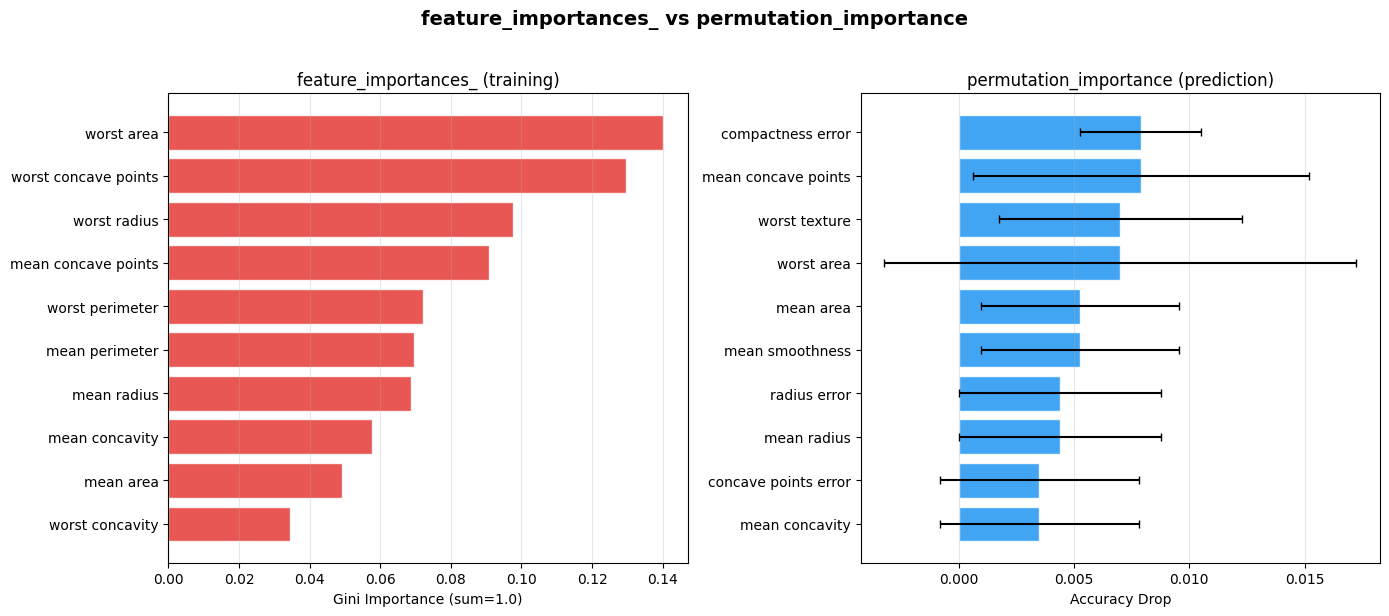

In [9]:
# 시각화: 두 방법 나란히 비교
top_n = 10

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: feature_importances_
top_tree = sorted_idx[:top_n]
axes[0].barh(
    range(top_n), tree_importances[top_tree[::-1]],
    color="#E53935", alpha=0.85, edgecolor="white",
)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([feature_names[i] for i in top_tree[::-1]])
axes[0].set_xlabel("Gini Importance (sum=1.0)")
axes[0].set_title("feature_importances_ (training)")
axes[0].grid(True, alpha=0.3, axis="x")

# 오른쪽: permutation importance
top_perm = perm_sorted_idx[:top_n]
axes[1].barh(
    range(top_n), perm_result.importances_mean[top_perm[::-1]],
    xerr=perm_result.importances_std[top_perm[::-1]],
    color="#2196F3", alpha=0.85, edgecolor="white", capsize=3,
)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feature_names[i] for i in top_perm[::-1]])
axes[1].set_xlabel("Accuracy Drop")
axes[1].set_title("permutation_importance (prediction)")
axes[1].grid(True, alpha=0.3, axis="x")

plt.suptitle(
    "feature_importances_ vs permutation_importance",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

---
## Step 8. 모델 비의존적 해석 — 4개 모델에 순열 중요도 적용

순열 중요도의 핵심 강점: **어떤 모델이든** 동일한 방법으로 피처 중요도 측정

**⚠ k-NN에는 feature_importances_가 없다. 하지만 순열 중요도는 가능하다.**

| 모델 | feature_importances_ | 순열 중요도 |
|------|---------------------|------------|
| 로지스틱 회귀 | ✗ (계수는 별도) | ✓ |
| k-NN | ✗ (없음) | ✓ |
| 랜덤 포레스트 | ✓ | ✓ |
| 그래디언트 부스팅 | ✓ | ✓ |

In [10]:
models_perm = {
    "로지스틱 회귀": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(random_state=42, max_iter=10000)),
    ]),
    "k-NN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "랜덤 포레스트": Pipeline([
        ("model", RandomForestClassifier(n_estimators=100, random_state=42)),
    ]),
    "그래디언트 부스팅": Pipeline([
        ("model", GradientBoostingClassifier(random_state=42)),
    ]),
}

print("모델 비의존적 해석 — 4개 모델에 순열 중요도 적용")
print("=" * 70)

for name, pipe in models_perm.items():
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    perm = permutation_importance(
        pipe, X_test, y_test, n_repeats=10, random_state=42
    )
    top3_idx = np.argsort(perm.importances_mean)[::-1][:3]
    top3 = ", ".join(
        [f"{feature_names[i]} ({perm.importances_mean[i]:.4f})"
         for i in top3_idx]
    )
    print(f"\n  {name} (정확도: {acc:.4f})")
    print(f"    상위 3개: {top3}")

print()
print("=" * 70)
print()
print("→ 동일한 방법으로 모든 모델의 피처 중요도를 비교할 수 있다")
print("→ 이것이 「모델 비의존적(Model-agnostic)」 해석의 핵심 가치")

모델 비의존적 해석 — 4개 모델에 순열 중요도 적용

  로지스틱 회귀 (정확도: 0.9825)
    상위 3개: radius error (0.0377), worst texture (0.0316), area error (0.0289)

  k-NN (k=5) (정확도: 0.9561)
    상위 3개: area error (0.0053), radius error (0.0044), fractal dimension error (0.0035)

  랜덤 포레스트 (정확도: 0.9561)
    상위 3개: compactness error (0.0079), mean concave points (0.0079), worst texture (0.0070)

  그래디언트 부스팅 (정확도: 0.9561)
    상위 3개: worst concave points (0.0658), worst texture (0.0158), area error (0.0096)


→ 동일한 방법으로 모든 모델의 피처 중요도를 비교할 수 있다
→ 이것이 「모델 비의존적(Model-agnostic)」 해석의 핵심 가치


---
## Step 9. 가상 교육 데이터 생성 — 편향이 내재된 데이터

breast_cancer에는 보호 속성이 없으므로,
교육 현장의 **공정성 문제를 직접 체감**하기 위해 가상 데이터를 생성한다

### 차시 2 핵심 오해 교정
| 오해 | 교정 |
|------|------|
| "ML은 객관적" | ML = 거울. 데이터에 편향이 있으면 모델도 편향 |
| "보호 속성 제거 = 공정" | 대리 변수(Proxy Variable)로 간접 차별 여전히 가능 |
| "공정성은 기술적 문제" | 기술 + 윤리 + 맥락의 교차점. 사람의 판단이 필수 |

| 비유 | 이름을 가린다고 그 사람을 모르지 않는다 — 목소리·체형·습관으로 누군지 안다 |

In [11]:
np.random.seed(42)
n_students = 1000

gender = np.random.choice(["M", "F"], size=n_students, p=[0.5, 0.5])

attendance = np.where(
    gender == "M",
    np.random.normal(0.72, 0.15, n_students),
    np.random.normal(0.78, 0.12, n_students),
)
attendance = np.clip(attendance, 0, 1)

homework = np.where(
    gender == "M",
    np.random.normal(0.60, 0.20, n_students),
    np.random.normal(0.70, 0.18, n_students),
)
homework = np.clip(homework, 0, 1)

# 대리 변수: "방과후 활동 참여" — 사실 경제적 여유의 대리 변수
economic_proxy = np.random.normal(0.5, 0.2, n_students)
economic_proxy = np.clip(economic_proxy, 0, 1)

midterm = (0.3 * attendance + 0.3 * homework
           + 0.2 * economic_proxy + 0.2 * np.random.random(n_students))

# 타겟: 위험군 (의도적으로 성별 편향 주입)
risk_score = (
    -2.0 * attendance - 1.5 * homework - 0.5 * economic_proxy
    + 0.3 * (gender == "M").astype(float)
    + np.random.normal(0, 0.3, n_students)
)
y_edu = (risk_score > np.percentile(risk_score, 75)).astype(int)

print(f"가상 교육 데이터: {n_students}명")
print(f"위험군 비율: {y_edu.mean():.1%}")
print()
print("성별별 위험군 비율:")
for g in ["M", "F"]:
    mask = gender == g
    rate = y_edu[mask].mean()
    print(f"  {g}학생: {rate:.1%}  ({mask.sum()}명 중 {y_edu[mask].sum()}명)")
print()
print("→ 남학생 위험군 비율이 더 높다")
print("→ 가능성 A: 실제로 더 위험 / 가능성 B: 데이터 또는 모델의 편향")
print('→ 이것이 「이 모델은 공정한가?」의 핵심 질문')

가상 교육 데이터: 1000명
위험군 비율: 25.0%

성별별 위험군 비율:
  M학생: 41.0%  (503명 중 206명)
  F학생: 8.9%  (497명 중 44명)

→ 남학생 위험군 비율이 더 높다
→ 가능성 A: 실제로 더 위험 / 가능성 B: 데이터 또는 모델의 편향
→ 이것이 「이 모델은 공정한가?」의 핵심 질문


---
## Step 10. 집단별 성능 비교 — 전체 정확도만으로는 부족하다

**「전체 성능만 보면 편향을 놓친다! 보호 속성별로 성능을 분리하여 비교해야 한다」**

코드 구조 (간단하지만 매우 강력):
```python
mask = (gender == "F")
accuracy_score(y_test[mask], y_pred[mask])
```

**⚠ 4주차 원칙의 확장: 「전체 정확도만으로 판단하면 안 된다」 → 「집단별로도 분리해서 봐야 한다」**

In [12]:
edu_features = ["출석률", "과제제출률", "방과후활동", "중간고사"]
X_edu = np.column_stack([attendance, homework, economic_proxy, midterm])

X_edu_tr, X_edu_te, y_edu_tr, y_edu_te, g_tr, g_te = train_test_split(
    X_edu, y_edu, gender, test_size=0.3, random_state=42
)

rf_edu = RandomForestClassifier(n_estimators=100, random_state=42)
rf_edu.fit(X_edu_tr, y_edu_tr)
y_edu_pred = rf_edu.predict(X_edu_te)

mask_m = g_te == "M"
mask_f = g_te == "F"

print(f"전체 정확도: {accuracy_score(y_edu_te, y_edu_pred):.4f}")
print("→ 전체만 보면 좋아 보인다. 하지만 집단별로 분리하면?")
print()
print("집단별 성능 비교")
print("=" * 60)
print(f"{'지표':<12} {'전체':>8} {'남학생':>8} {'여학생':>8} {'차이':>8}")
print("-" * 60)

for metric_name, fn in [
    ("정확도", accuracy_score),
    ("정밀도", lambda y, p: precision_score(y, p, zero_division=0)),
    ("재현율", lambda y, p: recall_score(y, p, zero_division=0)),
    ("F1", lambda y, p: f1_score(y, p, zero_division=0)),
]:
    total = fn(y_edu_te, y_edu_pred)
    val_m = fn(y_edu_te[mask_m], y_edu_pred[mask_m])
    val_f = fn(y_edu_te[mask_f], y_edu_pred[mask_f])
    diff = abs(val_m - val_f)
    warn = "⚠" if diff > 0.05 else ""
    print(f"{metric_name:<12} {total:>8.4f} {val_m:>8.4f} "
          f"{val_f:>8.4f} {diff:>7.4f} {warn}")

pred_m = y_edu_pred[mask_m].mean()
pred_f = y_edu_pred[mask_f].mean()
print()
print(f"위험군 예측 비율: 남학생 {pred_m:.1%} / 여학생 {pred_f:.1%}")
print("=" * 60)

전체 정확도: 0.8200
→ 전체만 보면 좋아 보인다. 하지만 집단별로 분리하면?

집단별 성능 비교
지표                 전체      남학생      여학생       차이
------------------------------------------------------------
정확도            0.8200   0.7484   0.8966  0.1482 ⚠
정밀도            0.7222   0.8222   0.2222  0.6000 ⚠
재현율            0.5000   0.5441   0.2000  0.3441 ⚠
F1             0.5909   0.6549   0.2105  0.4443 ⚠

위험군 예측 비율: 남학생 29.0% / 여학생 6.2%


---
## Step 11. 공정성 정의 3가지 점검

**「공정하다」의 정의가 여러 가지다 — 서로 충돌할 수 있다!**

| 정의 | 설명 | 점검 방법 |
|------|------|----------|
| ① 비율 동등 (Demographic Parity) | 위험군 예측 **비율**이 집단 간 동등 | `pred_rate_M ≈ pred_rate_F` |
| ② 정확도 동등 (Equalized Odds) | 정확도/재현율이 집단 간 동등 | `accuracy_M ≈ accuracy_F` |
| ③ 개인 공정성 (Individual Fairness) | 비슷한 학생 → 비슷한 예측 | 유사 학생 쌍 비교 |

**⚠ 모든 정의를 동시에 만족시키는 것은 수학적으로 불가능한 경우가 많다**

→ 「어떤 공정성을 우선할 것인가?」는 기술적 결정이 아니라 **가치의 결정**

In [13]:
acc_m = accuracy_score(y_edu_te[mask_m], y_edu_pred[mask_m])
acc_f = accuracy_score(y_edu_te[mask_f], y_edu_pred[mask_f])
rec_m = recall_score(y_edu_te[mask_m], y_edu_pred[mask_m], zero_division=0)
rec_f = recall_score(y_edu_te[mask_f], y_edu_pred[mask_f], zero_division=0)

print("공정성 정의 3가지 점검")
print("=" * 60)

# 정의 1
print()
print("① 비율 동등 (Demographic Parity)")
print(f"   남학생 위험군 예측 비율: {pred_m:.3f}")
print(f"   여학생 위험군 예측 비율: {pred_f:.3f}")
print(f"   비율 차이: {abs(pred_m - pred_f):.3f}")
dp_pass = abs(pred_m - pred_f) < 0.05
print(f"   판정: {'통과 (5%p 이내)' if dp_pass else '위반'}")

# 정의 2
print()
print("② 정확도 동등 (Equalized Odds)")
print(f"   남학생 정확도: {acc_m:.3f} / 여학생 정확도: {acc_f:.3f} "
      f"(차이: {abs(acc_m-acc_f):.3f})")
print(f"   남학생 재현율: {rec_m:.3f} / 여학생 재현율: {rec_f:.3f} "
      f"(차이: {abs(rec_m-rec_f):.3f})")
eo_pass = abs(acc_m - acc_f) < 0.05 and abs(rec_m - rec_f) < 0.05
print(f"   판정: {'통과 (5%p 이내)' if eo_pass else '위반'}")

# 정의 3 — 간이 점검
print()
print("③ 개인 공정성 (Individual Fairness)")
print('   "비슷한 학생은 비슷한 예측을 받아야 한다"')
n_pairs, n_diff = 0, 0
for i in range(len(X_edu_te)):
    if g_te[i] == "M" and n_pairs < 200:
        dists = np.sqrt(np.sum((X_edu_te - X_edu_te[i])**2, axis=1))
        for j in np.where((g_te == "F") & (dists < 0.15))[0]:
            n_pairs += 1
            if y_edu_pred[i] != y_edu_pred[j]:
                n_diff += 1
            if n_pairs >= 200:
                break
if n_pairs > 0:
    print(f"   유사 학생 쌍: {n_pairs}쌍, 예측 다른 쌍: {n_diff}쌍 ({n_diff/n_pairs:.1%})")

print()
print("=" * 60)
print()
print("→ 세 정의가 서로 충돌할 수 있다")
print('→ "어떤 공정성을 우선할 것인가?"는 기술이 아니라 가치의 결정')
print("→ 정답이 없다는 것 자체가 핵심 — 명시적 인식이 중요")

공정성 정의 3가지 점검

① 비율 동등 (Demographic Parity)
   남학생 위험군 예측 비율: 0.290
   여학생 위험군 예측 비율: 0.062
   비율 차이: 0.228
   판정: 위반

② 정확도 동등 (Equalized Odds)
   남학생 정확도: 0.748 / 여학생 정확도: 0.897 (차이: 0.148)
   남학생 재현율: 0.544 / 여학생 재현율: 0.200 (차이: 0.344)
   판정: 위반

③ 개인 공정성 (Individual Fairness)
   "비슷한 학생은 비슷한 예측을 받아야 한다"
   유사 학생 쌍: 200쌍, 예측 다른 쌍: 33쌍 (16.5%)


→ 세 정의가 서로 충돌할 수 있다
→ "어떤 공정성을 우선할 것인가?"는 기술이 아니라 가치의 결정
→ 정답이 없다는 것 자체가 핵심 — 명시적 인식이 중요


---
## Step 12. 대리 변수 점검 — 순열 중요도 + 상관분석

**차시 1 → 차시 2 연결:**
순열 중요도로 확인한 **중요 피처**가 **보호 속성의 대리 변수**인지 의심하는 것이 13주차 핵심!

| 비유 | 이름을 가린다고 그 사람을 모르지 않는다 — 보호 속성 제거는 「해법」이 아니다 |

In [14]:
perm_edu = permutation_importance(
    rf_edu, X_edu_te, y_edu_te, n_repeats=10, random_state=42
)

perm_edu_sorted = np.argsort(perm_edu.importances_mean)[::-1]

print("교육 데이터 — 순열 중요도 결과")
print("=" * 50)
for i, idx in enumerate(perm_edu_sorted):
    print(f"  {i+1}위  {edu_features[idx]:<12} → "
          f"{perm_edu.importances_mean[idx]:.4f} "
          f"(±{perm_edu.importances_std[idx]:.4f})")

print()
print("대리 변수 점검: 각 피처와 성별의 상관")
print("-" * 50)

gender_numeric = (g_te == "M").astype(float)
for i, feat_name in enumerate(edu_features):
    corr = np.corrcoef(X_edu_te[:, i], gender_numeric)[0, 1]
    warn = "⚠ 대리 변수 의심" if abs(corr) > 0.1 else ""
    print(f"  {feat_name:<12} ↔ 성별 상관: {corr:+.3f}  {warn}")

print()
print("→ 피처가 직접 차별적이지 않아도 대리 변수로 작동할 수 있다")
print("→ 보호 속성을 제거하는 것만으로는 공정성 확보 불가")

교육 데이터 — 순열 중요도 결과
  1위  과제제출률        → 0.0657 (±0.0126)
  2위  출석률          → 0.0650 (±0.0165)
  3위  중간고사         → 0.0130 (±0.0096)
  4위  방과후활동        → 0.0107 (±0.0121)

대리 변수 점검: 각 피처와 성별의 상관
--------------------------------------------------
  출석률          ↔ 성별 상관: -0.268  ⚠ 대리 변수 의심
  과제제출률        ↔ 성별 상관: -0.282  ⚠ 대리 변수 의심
  방과후활동        ↔ 성별 상관: -0.021  
  중간고사         ↔ 성별 상관: -0.284  ⚠ 대리 변수 의심

→ 피처가 직접 차별적이지 않아도 대리 변수로 작동할 수 있다
→ 보호 속성을 제거하는 것만으로는 공정성 확보 불가


---
## Step 13. 데이터 드리프트 시뮬레이션

**「모델을 한 번 만들면 영원히 쓸 수 있는가?」** → 아니다!

모델은 학습 당시의 데이터에 최적화되어 있다.
시간이 지나 현실이 변하면 성능이 떨어진다 = **데이터 드리프트(Data Drift)**

### 3가지 유형
| 유형 | 설명 | 예시 |
|------|------|------|
| ① 피처 분포 변화 | 입력값 분포가 변함 | 평균 출석률 90%→75% |
| ② 타겟 분포 변화 | 결과 분포가 변함 | 학업 부진 비율 10%→25% |
| ③ 관계 변화 ★ | 입력→결과 관계가 변함 | 출석↑→성적↑ 관계 약화 |

| 비유 | 모델의 「건강검진」 — 사람도 매년 검진을 받듯이, 모델도 주기적으로 성능을 확인 |

**⚠ 교육 데이터는 학기·연도 단위로 변화 → 최소 매 학년도마다 모델 성능 재확인 권장**

In [15]:
# breast_cancer 모델에 노이즈를 주입하여 드리프트 시뮬레이션
baseline = rf.score(X_test, y_test)

years = ["2020(배포)", "2021", "2022", "2023", "2024", "2025"]
noise_levels = [0, 0.3, 0.6, 1.0, 1.5, 2.0]
drift_scores = []

print(f"기준 성능 (배포 시점): {baseline:.4f}")
print()
print("데이터 드리프트 시뮬레이션 — 시간 경과별 성능 변화")
print("=" * 55)
print(f"{'시점':<14} {'노이즈':>8} {'정확도':>10} {'진단':>12}")
print("-" * 55)

for year, noise in zip(years, noise_levels):
    X_drifted = X_test + np.random.normal(0, noise, X_test.shape) * X_test.std(axis=0)
    X_drifted = np.clip(X_drifted, 0, None)
    score = rf.score(X_drifted, y_test)
    drift_scores.append(score)

    if noise == 0:
        status = "기준선"
    elif score > baseline - 0.03:
        status = "허용"
    elif score > baseline - 0.10:
        status = "⚠ 경고"
    else:
        status = "재학습!"

    print(f"{year:<14} {noise:>8.1f} {score:>10.4f} {status:>12}")

print("=" * 55)
print()
print("→ 시간이 지날수록 성능이 하락한다")
print("→ 교육 데이터는 학기·연도 단위로 변화")
print("→ 최소 매 학년도마다 모델 성능 재확인 권장")

기준 성능 (배포 시점): 0.9561

데이터 드리프트 시뮬레이션 — 시간 경과별 성능 변화
시점                  노이즈        정확도           진단
-------------------------------------------------------
2020(배포)            0.0     0.9561          기준선
2021                0.3     0.9386           허용
2022                0.6     0.9211         ⚠ 경고
2023                1.0     0.8509         재학습!
2024                1.5     0.7632         재학습!
2025                2.0     0.7982         재학습!

→ 시간이 지날수록 성능이 하락한다
→ 교육 데이터는 학기·연도 단위로 변화
→ 최소 매 학년도마다 모델 성능 재확인 권장


---
## Step 14. 성능 모니터링 시각화

**「만들고 잊으면 안 된다」**

### 모니터링 4단계
| Step | 내용 |
|------|------|
| 1 | 기준 성능(Baseline) 기록 |
| 2 | 주기적 성능 확인 (새 데이터로 예측 → 실제 결과와 비교) |
| 3 | 기준선과 비교 (허용 / 경고 / 재학습) |
| 4 | 재학습 판단 — 고위험: 3%p 기준 / 저위험: 10%p 기준 |

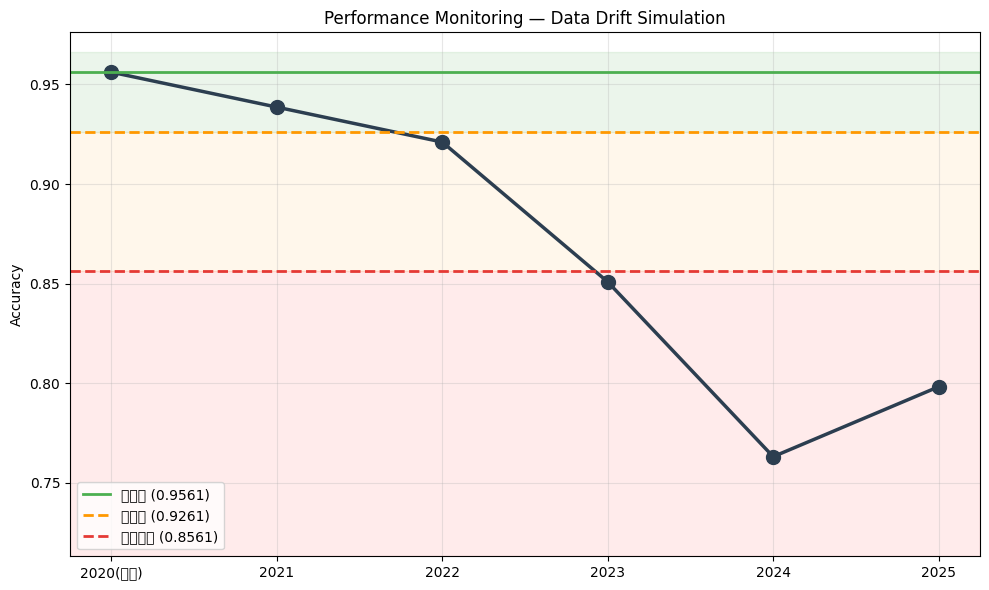

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(len(years)), drift_scores, "o-", color="#2c3e50",
        linewidth=2.5, markersize=10)

ax.axhline(y=baseline, color="#4CAF50", linestyle="-", linewidth=2,
           label=f"기준선 ({baseline:.4f})")
ax.axhline(y=baseline - 0.03, color="#FF9800", linestyle="--", linewidth=2,
           label=f"경고선 ({baseline-0.03:.4f})")
ax.axhline(y=baseline - 0.10, color="#E53935", linestyle="--", linewidth=2,
           label=f"재학습선 ({baseline-0.10:.4f})")

ax.axhspan(baseline - 0.03, baseline + 0.01, alpha=0.08, color="green")
ax.axhspan(baseline - 0.10, baseline - 0.03, alpha=0.08, color="orange")
ax.axhspan(min(drift_scores) - 0.05, baseline - 0.10, alpha=0.08, color="red")

ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel("Accuracy")
ax.set_title("Performance Monitoring — Data Drift Simulation")
ax.set_ylim(min(drift_scores) - 0.05, baseline + 0.02)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 15. 의사결정 한계 — 예측 확률 분석

**13주차 전체에서 가장 중요한 메시지:**

> **모델의 예측 ≠ 최종 결정**

| # | 이유 |
|---|------|
| ❶ | 모델은 「확률」을 예측 — 73%는 "높다"이지 "확실하다"가 아님 |
| ❷ | 모델은 「맥락」을 모른다 — 같은 출석률 60%도 상황에 따라 완전히 다름 |
| ❸ | 데이터에 없는 요인 — 동기·가정환경·정서 상태는 피처에 없음 |
| ❹ | 편향 가능성 (차시 2) — 모델 예측을 그대로 따르면 편향이 자동화·규모화 |
| ❺ | 예언의 자기 실현 — "위험군" 레이블 → 기대 하락 → 실제 성적 하락 |

**✓ 올바른 접근: ML 예측 + 교사의 전문적 판단 + 추가 정보 수집 = 최종 의사결정**

| "ML = 의사결정의 재료 중 하나" — 고위험 결정에서는 절대 모델 예측만으로 결정 금지 |

In [17]:
proba = rf_edu.predict_proba(X_edu_te)[:, 1]
pred = rf_edu.predict(X_edu_te)

borderline = (proba > 0.4) & (proba < 0.6)

print(f"전체 학생 {len(y_edu_te)}명 중")
print(f"확률 0.4~0.6 (경계 근처) 학생: {borderline.sum()}명 "
      f"({borderline.sum()/len(y_edu_te):.1%})")
print()
print("→ 이 학생들은 위험군/안전군 사이에서 아슬아슬한 학생들")
print("→ 0.5 기준 이분법 분류 시 정보 손실 발생")
print()

print("경계 근처 학생 예시 (확률 0.4~0.6)")
print("=" * 60)
print(f"{'번호':>5} {'출석':>6} {'과제':>6} {'방과후':>6} "
      f"{'확률':>6} {'예측':>5} {'실제':>5}")
print("-" * 60)

border_idx = np.where(borderline)[0][:8]
for idx in border_idx:
    actual = "위험" if y_edu_te[idx] == 1 else "안전"
    predicted = "위험" if pred[idx] == 1 else "안전"
    match = "✓" if pred[idx] == y_edu_te[idx] else "✗"
    print(f"{idx:>5} {X_edu_te[idx,0]:>6.2f} {X_edu_te[idx,1]:>6.2f} "
          f"{X_edu_te[idx,2]:>6.2f} {proba[idx]:>6.2f} "
          f"{predicted:>5} {actual:>4} {match}")

print("=" * 60)
print()
print("→ 같은 출석률 0.60이라도:")
print('  "원래 결석형" vs "일시적 결석 후 회복 중"은 완전히 다름')
print("→ 교사만이 이 맥락을 알고 있다")

전체 학생 300명 중
확률 0.4~0.6 (경계 근처) 학생: 31명 (10.3%)

→ 이 학생들은 위험군/안전군 사이에서 아슬아슬한 학생들
→ 0.5 기준 이분법 분류 시 정보 손실 발생

경계 근처 학생 예시 (확률 0.4~0.6)
   번호     출석     과제    방과후     확률    예측    실제
------------------------------------------------------------
    1   0.51   0.76   0.63   0.45    안전   위험 ✗
    5   0.84   0.42   0.29   0.49    안전   안전 ✓
    8   0.56   0.69   0.55   0.44    안전   위험 ✗
   17   0.63   0.66   0.20   0.44    안전   위험 ✗
   23   0.72   0.67   0.33   0.43    안전   위험 ✗
   28   0.58   0.64   0.30   0.58    위험   위험 ✓
   37   0.70   0.59   0.46   0.41    안전   안전 ✓
   50   0.91   0.33   0.62   0.52    위험   안전 ✗

→ 같은 출석률 0.60이라도:
  "원래 결석형" vs "일시적 결석 후 회복 중"은 완전히 다름
→ 교사만이 이 맥락을 알고 있다


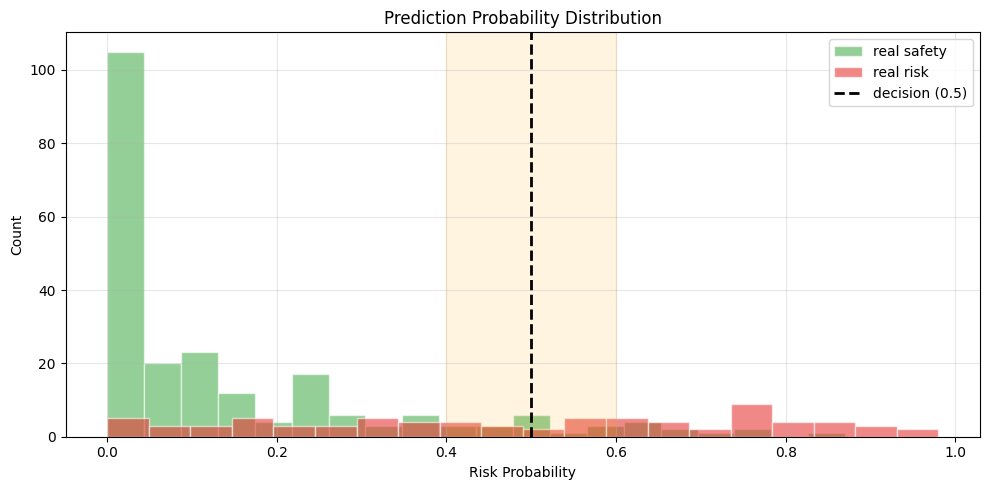

In [18]:
# 예측 확률 분포 시각화
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(proba[y_edu_te == 0], bins=20, alpha=0.6, color="#4CAF50",
        label="real safety", edgecolor="white")
ax.hist(proba[y_edu_te == 1], bins=20, alpha=0.6, color="#E53935",
        label="real risk", edgecolor="white")
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=2,
           label="decision (0.5)")
ax.axvspan(0.4, 0.6, alpha=0.12, color="orange", label="")

ax.set_xlabel("Risk Probability")
ax.set_ylabel("Count")
ax.set_title("Prediction Probability Distribution")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 16. 13주차 전체 종합

### 세 차시가 하나의 체계를 이룬다
| 차시 | 질문 | 도구 | 핵심 메시지 |
|------|------|------|------------|
| 차시 1 | 왜 이 예측을? | 순열 중요도, 글로벌/로컬 해석 | 예측 근거를 설명할 수 있어야 한다 |
| 차시 2 | 공정한가? | 집단별 성능 비교, 대리변수 점검 | ML은 객관적이지 않다. 공정성은 가치의 결정 |
| 차시 3 | 책임 있게? | 모니터링, 의사결정 한계 | 모델은 참고, 최종 결정은 사람이 |

### 차시 간 연결
1. 순열 중요도로 **중요 피처 확인** (차시 1)
2. 그 피처가 **대리 변수인지 의심** (차시 2)
3. 집단별 성능 비교로 **편향 점검** (차시 2)
4. 배포 후 **모니터링** + 최종 결정은 교사가 (차시 3)

### 최종 메시지

> **ML은 도구이다.**
> 망치가 집을 짓는 것이 아니라 목수가 망치를 사용하여 집을 짓는 것처럼,
> ML이 의사결정을 하는 것이 아니라 교사가 ML을 활용하여 학생을 돕는 것이다.

| 기술적 역량 (2~12주차) | + | 비판적 시각 (13주차) | = | 「ML을 올바르게 사용하는 교사」 |

**⚠ 13주차는 「덤」이 아니다 — 기술을 쌓은 뒤 반드시 따라오는 「책임」의 단계**

In [19]:
print("=" * 60)
print("13주차 전체 종합 — 「책임 있는 ML」 체크리스트")
print("=" * 60)
print()
print("  [해석]")
print("    □ 순열 중요도를 계산했는가?")
print("    □ 상위 피처가 도메인 지식과 일치하는가?")
print("    □ feature_importances_와 비교했는가 (트리 모델)?")
print()
print("  [공정성]")
print("    □ 보호 속성별 성능을 분리 비교했는가?")
print("    □ 중요 피처가 대리 변수가 아닌지 점검했는가?")
print("    □ 어떤 공정성 정의를 우선하는지 인식했는가?")
print()
print("  [배포]")
print("    □ 기준 성능(Baseline)을 기록했는가?")
print("    □ 모니터링 주기를 결정했는가?")
print("    □ 재학습 기준(임계값)을 설정했는가?")
print()
print("  [의사결정]")
print("    □ 모델 예측을 '참고'로 사용하는가?")
print("    □ 교사의 전문적 판단을 반영하는 절차가 있는가?")
print("    □ 고위험 결정에서 추가 정보를 수집하는가?")
print()
print("=" * 60)
print()
print("⚠ 주의: 공정성 점검은 데이터, 맥락, 보호 속성에 따라 달라집니다.")
print("  공정성의 정의는 하나가 아니며 서로 충돌할 수 있습니다.")
print("  모델 예측은 최종 결정이 아닙니다.")
print("  항상 집단별 성능을 확인하고, 대리 변수를 의심하고,")
print("  최종 결정은 사람이 내리는 것이 정답입니다.")

13주차 전체 종합 — 「책임 있는 ML」 체크리스트

  [해석]
    □ 순열 중요도를 계산했는가?
    □ 상위 피처가 도메인 지식과 일치하는가?
    □ feature_importances_와 비교했는가 (트리 모델)?

  [공정성]
    □ 보호 속성별 성능을 분리 비교했는가?
    □ 중요 피처가 대리 변수가 아닌지 점검했는가?
    □ 어떤 공정성 정의를 우선하는지 인식했는가?

  [배포]
    □ 기준 성능(Baseline)을 기록했는가?
    □ 모니터링 주기를 결정했는가?
    □ 재학습 기준(임계값)을 설정했는가?

  [의사결정]
    □ 모델 예측을 '참고'로 사용하는가?
    □ 교사의 전문적 판단을 반영하는 절차가 있는가?
    □ 고위험 결정에서 추가 정보를 수집하는가?


⚠ 주의: 공정성 점검은 데이터, 맥락, 보호 속성에 따라 달라집니다.
  공정성의 정의는 하나가 아니며 서로 충돌할 수 있습니다.
  모델 예측은 최종 결정이 아닙니다.
  항상 집단별 성능을 확인하고, 대리 변수를 의심하고,
  최종 결정은 사람이 내리는 것이 정답입니다.
